# Predição de Aprovação Escolar

Este notebook realiza análise exploratória, tratamento de dados, modelagem e avaliação para prever a aprovação de estudantes com base em dados de desempenho escolar.

## Inicialização e Importações 

In [3]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)

from sklearn import __version__ as skl_version
print("scikit-learn:", skl_version)

pandas: 2.2.0
numpy: 1.26.4
matplotlib: 3.8.3
seaborn: 0.12.2
scikit-learn: 1.7.0


In [1]:
# Bibliotecas de manipulação e visualização de dados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas de machine learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuração de gráficos
sns.set_palette('husl')
%matplotlib inline

## Carregamento dos Dados

In [2]:
# Altere o caminho se necessário
df_mat = pd.read_csv('dados/raw/student-mat.csv', sep=';')
df_por = pd.read_csv('dados/raw/student-por.csv', sep=';')

print('Dimensões dos dados de matemática:', df_mat.shape)
print('Dimensões dos dados de português:', df_por.shape)

Dimensões dos dados de matemática: (395, 33)
Dimensões dos dados de português: (649, 33)


## Análise Exploratória

In [10]:
#Visualização Inicial

print('Primeiras linhas dos dados de matemática:')
display(df_mat.head())

print('\nPrimeiras linhas dos dados de português:')
display(df_por.head())

print('\nEstatísticas descritivas dos dados de matemática:')
display(df_mat.describe())

print('\nEstatísticas descritivas dos dados de português:')
display(df_por.describe())

print('\nValores ausentes nos dados de matemática:')
print(df_mat.isnull().sum())

print('\nValores ausentes nos dados de português:')
print(df_por.isnull().sum())

Primeiras linhas dos dados de matemática:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Primeiras linhas dos dados de português:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13



Estatísticas descritivas dos dados de matemática:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



Estatísticas descritivas dos dados de português:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000



Valores ausentes nos dados de matemática:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Valores ausentes nos dados de português:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel

C:\Users\kalle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kalle\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


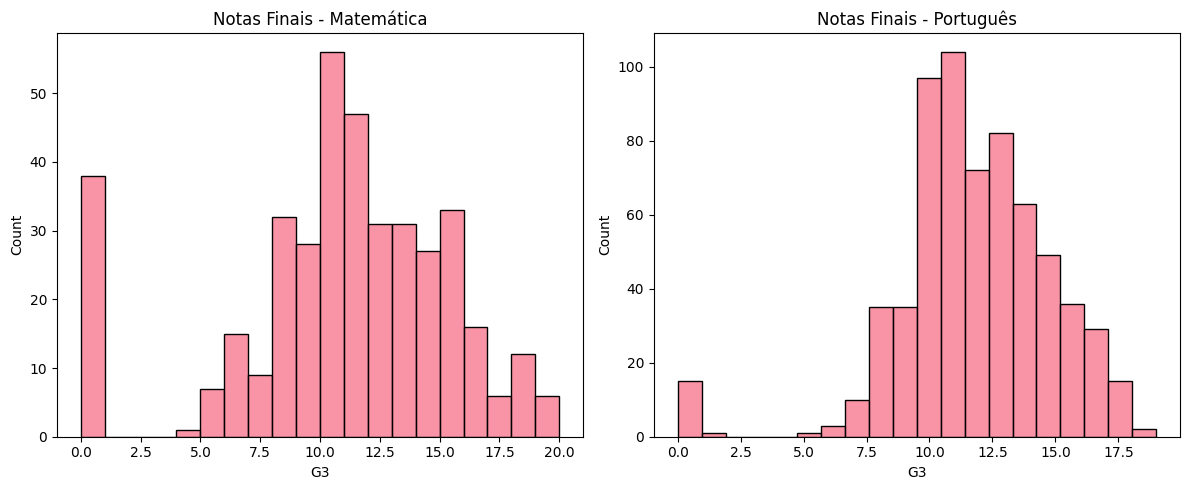

In [11]:
#Visualização Gráfica

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_mat['G3'], bins=20)
plt.title('Notas Finais - Matemática')
plt.subplot(1, 2, 2)
sns.histplot(df_por['G3'], bins=20)
plt.title('Notas Finais - Português')
plt.tight_layout()
plt.show()

In [15]:
#Tradução de colunas

traducao = {
    'age': 'idade',
    'Medu': 'escolaridade_mae',
    'Fedu': 'escolaridade_pai',
    'traveltime': 'tempo_viagem',
    'studytime': 'tempo_estudo',
    'failures': 'reprovações',
    'famrel': 'relacao_familiar',
    'freetime': 'tempo_livre',
    'goout': 'sair_com_amigos',
    'Dalc': 'alcool_dia',
    'Walc': 'alcool_fim_semana',
    'health': 'saude',
    'absences': 'faltas',
    'G1': 'nota_1',
    'G2': 'nota_2',
    'G3': 'nota_final'
}

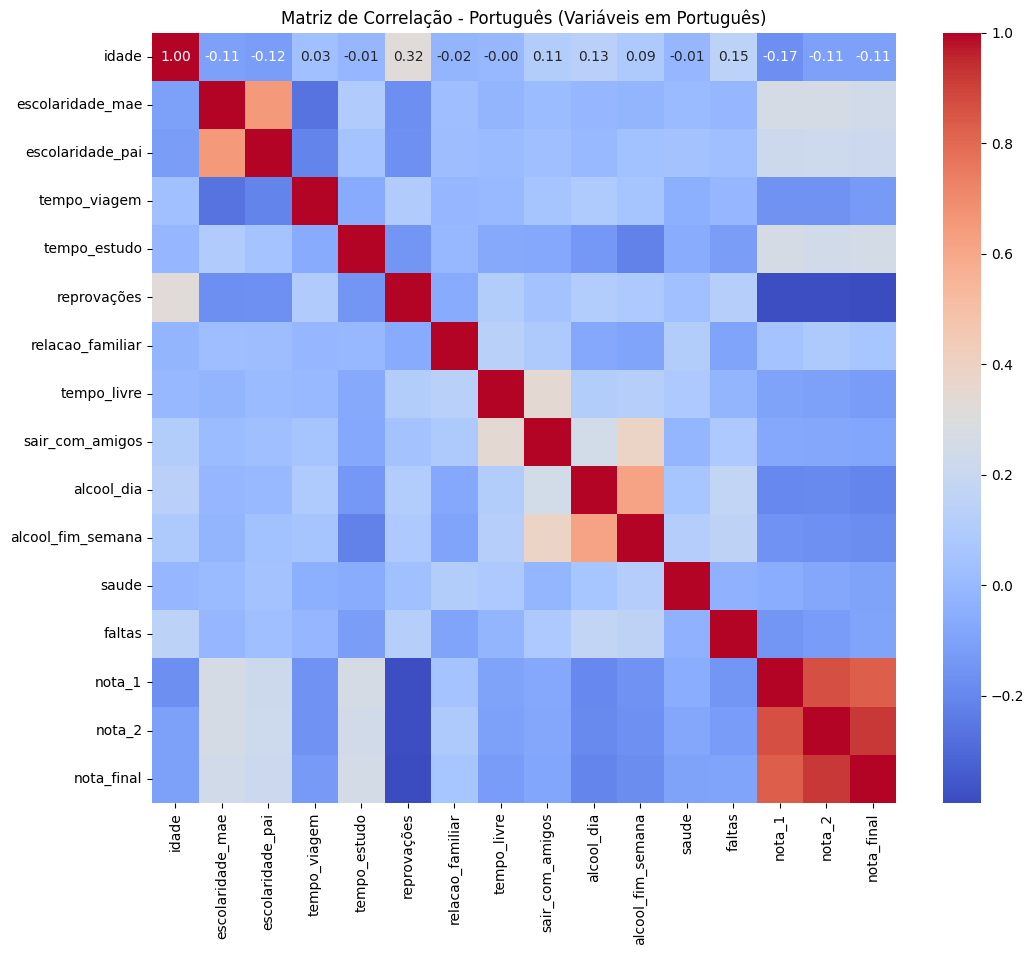

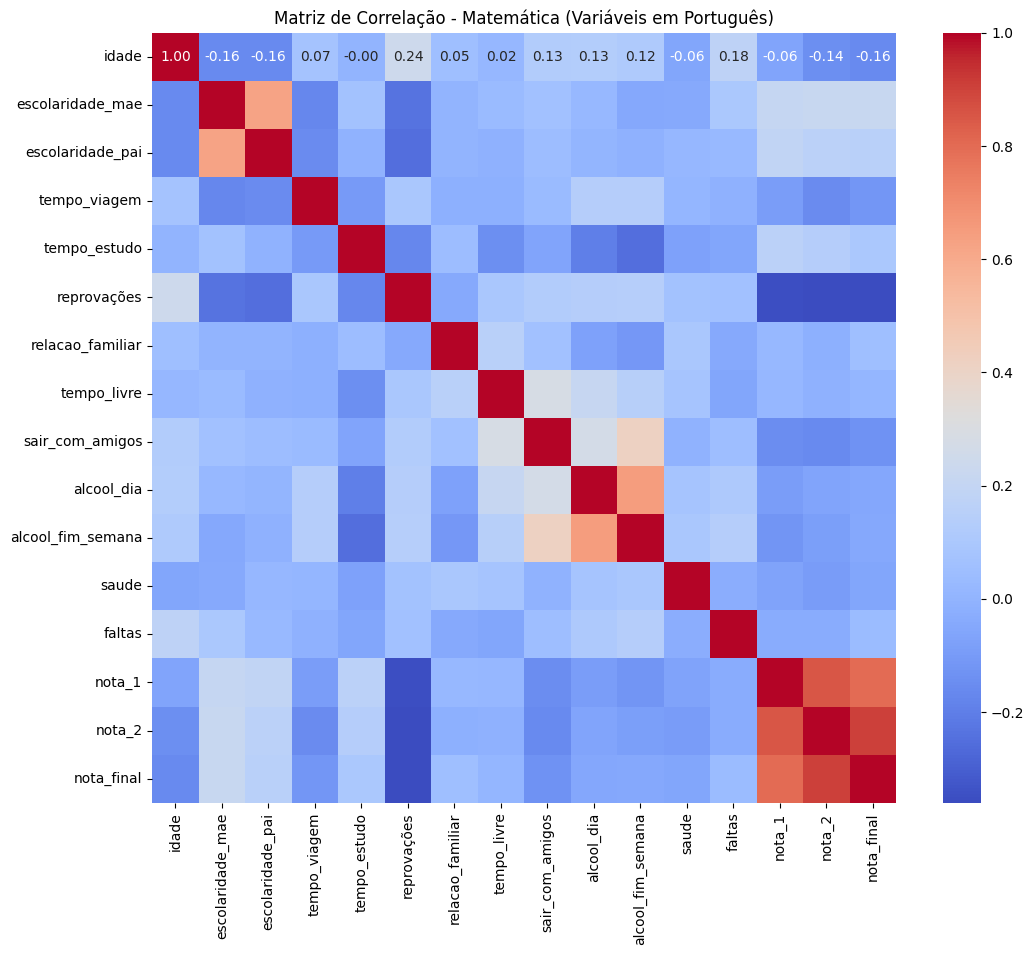

In [16]:
# Matriz de correlação para português com nomes em português
corr_por = df_por.select_dtypes(include=[np.number]).corr()
corr_por_pt = corr_por.rename(index=traducao, columns=traducao)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_por_pt, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Português (Variáveis em Português)')
plt.show()

#------------------------------------------------------------------------------

# Matriz de correlação para matemática com nomes em português
corr_mat = df_mat.select_dtypes(include=[np.number]).corr()
corr_mat_pt = corr_mat.rename(index=traducao, columns=traducao)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_mat_pt, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação - Matemática (Variáveis em Português)')
plt.show()


## Tratamento de Dados

In [25]:
def tratar_valores_ausentes(df):
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include=['object']).columns:
        df[col].fillna(df[col].mode()[0], inplace=True)
    return df

def criar_novas_features(df):
    df['media_notas'] = (df['G1'] + df['G2'] + df['G3']) / 3
    df['diff_G1_G2'] = df['G2'] - df['G1']
    df['diff_G2_G3'] = df['G3'] - df['G2']
    df['aprovado'] = (df['G3'] >= 10).astype(int)
    return df

# Garante que a coluna 'aprovado' é binária e do tipo inteiro
df['aprovado'] = (df['G3'] >= 10).astype(int)

def preparar_dados_modelagem(df):
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = le.fit_transform(df[col])
    scaler = StandardScaler()
    # Não normaliza a coluna 'aprovado'
    colunas_numericas = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'aprovado']
    df[colunas_numericas] = scaler.fit_transform(df[colunas_numericas])
    return df

# Aplicando o tratamento
df = df_mat.copy()  # ou df_por.copy() se preferir português
df = tratar_valores_ausentes(df)
df = criar_novas_features(df)
df = preparar_dados_modelagem(df)

print('Dados tratados e prontos para modelagem!')

Dados tratados e prontos para modelagem!


C:\Users\kalle\AppData\Local\Temp\ipykernel_12956\2014338660.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\kalle\AppData\Local\Temp\ipykernel_12956\2014338660.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

## Modelagem e Avaliação


Treinando Regressão Logística...
Acurácia: 0.9873417721518988
Precisão: 0.9811320754716981
Recall: 1.0
F1-Score: 0.9904761904761905


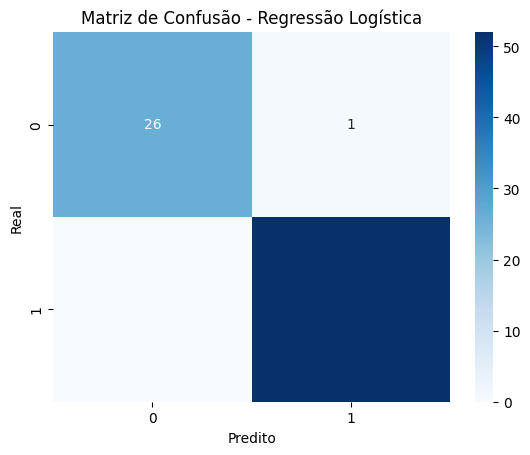


Treinando Random Forest...
Acurácia: 1.0
Precisão: 1.0
Recall: 1.0
F1-Score: 1.0


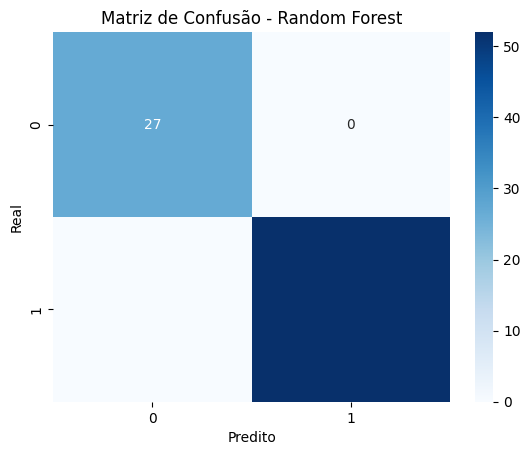


Treinando SVM...
Acurácia: 0.9240506329113924
Precisão: 0.9259259259259259
Recall: 0.9615384615384616
F1-Score: 0.9433962264150944


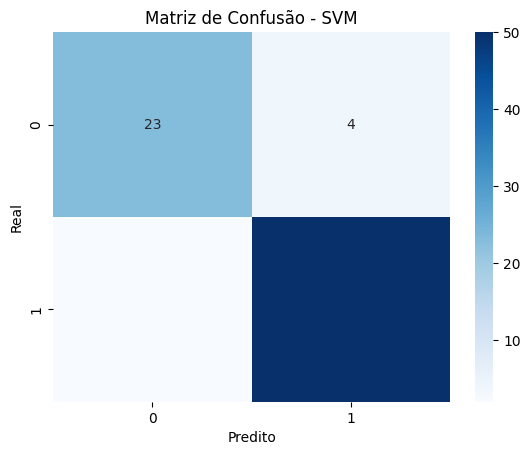

In [26]:
X = df.drop('aprovado', axis=1)
y = df['aprovado']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    'Regressão Logística': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

for nome, modelo in modelos.items():
    print(f'\nTreinando {nome}...')
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    print('Acurácia:', accuracy_score(y_test, y_pred))
    print('Precisão:', precision_score(y_test, y_pred))
    print('Recall:', recall_score(y_test, y_pred))
    print('F1-Score:', f1_score(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusão - {nome}')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.show()